# Weather Underground PWS: fetch, tidy, check

Hourly history for personal weather stations (PWS) from the Weather
Underground API, with clean column names, per-station precipitation totals and
a multi-variable dashboard. Needs `$WU_API_KEY`
(https://www.wunderground.com/member/api-keys) and network access.

Fetching and cleaning are `src/fetch/wu_functions.py`; figures and totals are
`src/fetch/wu_plotting.py`. For the curated OpenMesh PWS record (no key
needed) use `openmesh_data.ipynb`.

In [1]:
import sys
from datetime import datetime
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
from fetch import wu_functions as wu, wu_plotting as wup

## Configuration

Stations by ID, or every station in the published `pws_metadata.csv`
(`wu.get_station_list(wu.read_pws_metadata())`). The `history/hourly` endpoint
is chunked into 31-day requests, so any period works.

In [2]:
STATION_IDS = ["KNYNEWYO1805", "KNYNEWYO1288"]
START, END = datetime(2024, 1, 1), datetime(2024, 1, 30)
UNITS = "m"                                   # "m" metric, "e" imperial
OUTPUT_DIR = Path("../data/wu_pws")           # projects/data/openmesh_nyc/data/, git-ignored

## Fetch

In [3]:
results = wu.run_wu_pipeline(api_key=wu.api_key(), station_ids=STATION_IDS,
                             start_date=START, end_date=END, units=UNITS,
                             fetch_options={"historical": True})
stations = wu.station_frames(results)
first = stations[STATION_IDS[0]]["clean"]
print(f"{results['summary']['total_observations']:,} observations, "
      f"{len(stations)} stations, {first.shape[1]} columns")
first.head()

FETCHING DATA FROM WEATHER UNDERGROUND API

Fetching data for station: KNYNEWYO1805
  → Fetching historical data (2024-01-01 to 2024-01-30)...


    ✓ Historical data fetched (720 total observations)

Fetching data for station: KNYNEWYO1288
  → Fetching historical data (2024-01-01 to 2024-01-30)...


    ✓ Historical data fetched (720 total observations)
✓ Success: Fetched 1,440 observations in 1.0s
✓ Stations processed: 2/2

CONVERTING TO DATAFRAME WITH CLEAN NAMES

Processing station: KNYNEWYO1805


  ✓ Created DataFrame: 720 rows, 37 columns

Processing station: KNYNEWYO1288


  ✓ Created DataFrame: 720 rows, 37 columns

✓ Processed 2 station(s)
1,440 observations, 2 stations, 37 columns


,precip_rate,precip_total,time_local,time_utc,timestamp_unix,station_id,latitude,longitude,timezone,temp_avg,...,wind_gust_avg,wind_gust_high,wind_gust_low,wind_direction_avg,pressure_max,pressure_min,pressure_trend,solar_radiation_high,uv_index_high,qc_status
0,0.0,0.0,2024-01-01 00:58:23,2024-01-01 05:58:23+00:00,1704088703,KNYNEWYO1805,40.638,-74.035,America/New_York,5,...,5,6,3,95.0,1016.26,1016.26,0.0,0.0,0.0,1
1,0.0,0.0,2024-01-01 01:58:22,2024-01-01 06:58:22+00:00,1704092302,KNYNEWYO1805,40.638,-74.035,America/New_York,5,...,4,6,3,104.0,1015.92,1015.92,0.0,0.0,0.0,1
2,0.0,0.0,2024-01-01 02:58:21,2024-01-01 07:58:21+00:00,1704095901,KNYNEWYO1805,40.638,-74.035,America/New_York,5,...,3,5,3,124.0,1015.92,1015.92,0.0,0.0,0.0,1
3,0.0,0.0,2024-01-01 03:59:21,2024-01-01 08:59:21+00:00,1704099561,KNYNEWYO1805,40.638,-74.035,America/New_York,5,...,2,4,0,109.0,1015.58,1015.24,0.0,0.0,0.0,1
4,0.0,0.0,2024-01-01 04:59:18,2024-01-01 09:59:18+00:00,1704103158,KNYNEWYO1805,40.638,-74.035,America/New_York,5,...,1,3,0,115.0,1015.58,1015.24,0.0,0.0,0.0,1


## Precipitation

Rates are mm/h over one-hour records, so their sum is the accumulation in mm.
`check_data_quality` reports completeness against one record per hour and
gaps over two hours.

Compare totals with the ASOS airports (`asos_pipeline.ipynb`) before trusting
a station: for January 2024 the airports record 106-158 mm, KNYNEWYO1805
165 mm, and KNYNEWYO1288 ~500 mm with an 83 mm/h peak - three times its
neighbours, a station to flag rather than use as a reference.

KNYNEWYO1805: ✓ Quality: 100% complete, 0 gaps
KNYNEWYO1288: ✓ Quality: 100% complete, 0 gaps


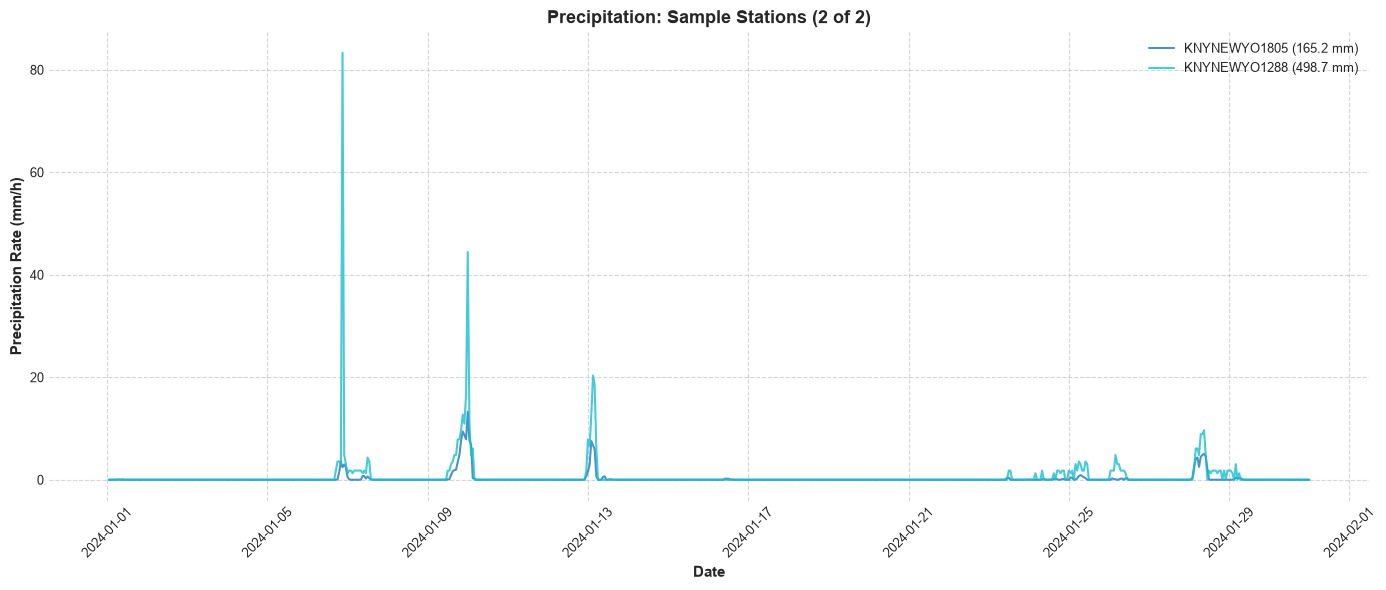

💧 KNYNEWYO1805: 165.2 mm total, 99 events
💧 KNYNEWYO1288: 498.7 mm total, 98 events


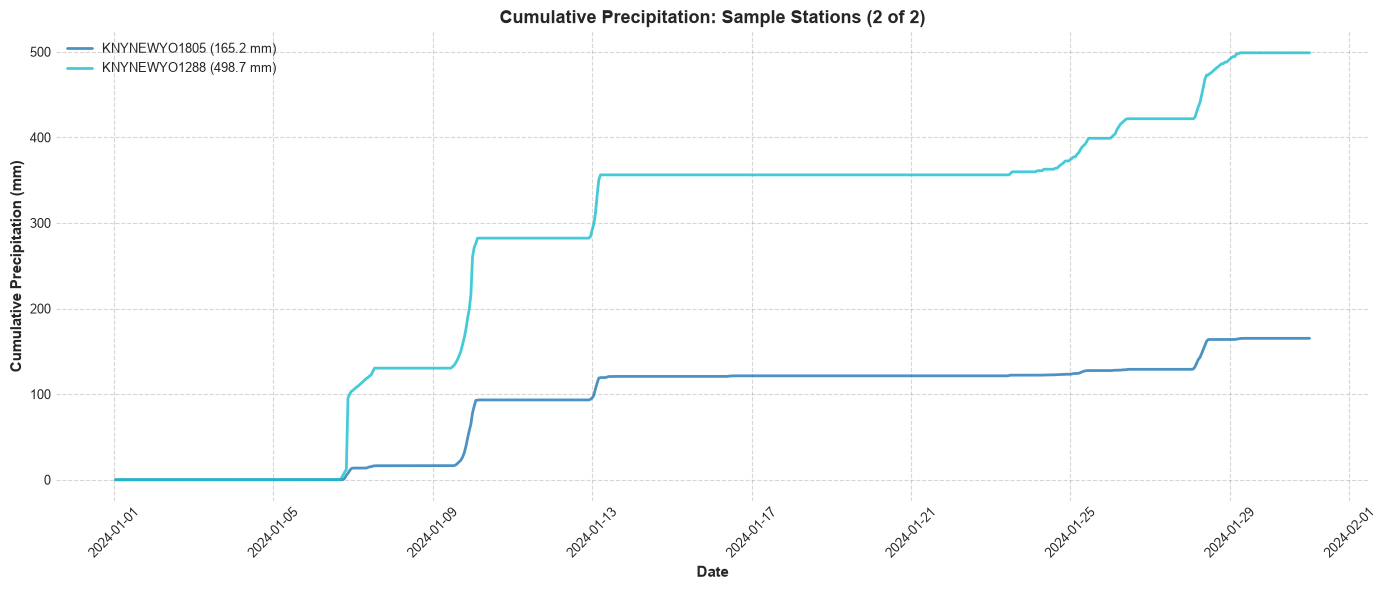

📈 KNYNEWYO1805: 165.2 mm total, 99 events
📈 KNYNEWYO1288: 498.7 mm total, 98 events


In [4]:
for sid, d in stations.items():
    print(sid, end=": ")
    wup.check_data_quality(d["clean"], START, END)
wup.plot_precipitation_analysis_multi(stations, units=UNITS, show=True)
wup.plot_cumulative_precipitation_multi(stations, units=UNITS, show=True)

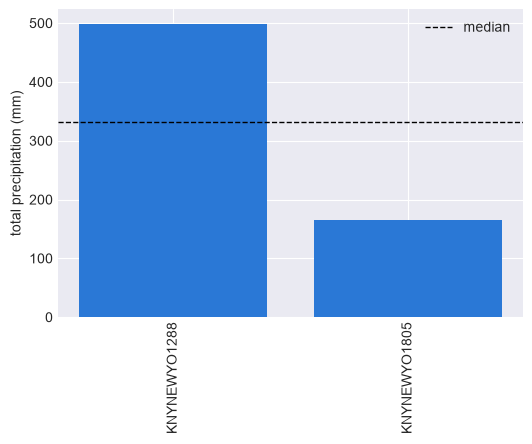

,station_id,total_precip,rain_hours,max_rate,mean_rate,days_with_rain,unit
1,KNYNEWYO1288,498.74,98,83.31,5.09,12,mm
0,KNYNEWYO1805,165.17,99,13.28,1.67,14,mm


In [5]:
totals = wup.station_accumulation_table(stations, units=UNITS)
wup.plot_station_accumulation(totals, show=True)
totals.round(2)

## Temperature, humidity, wind, rain

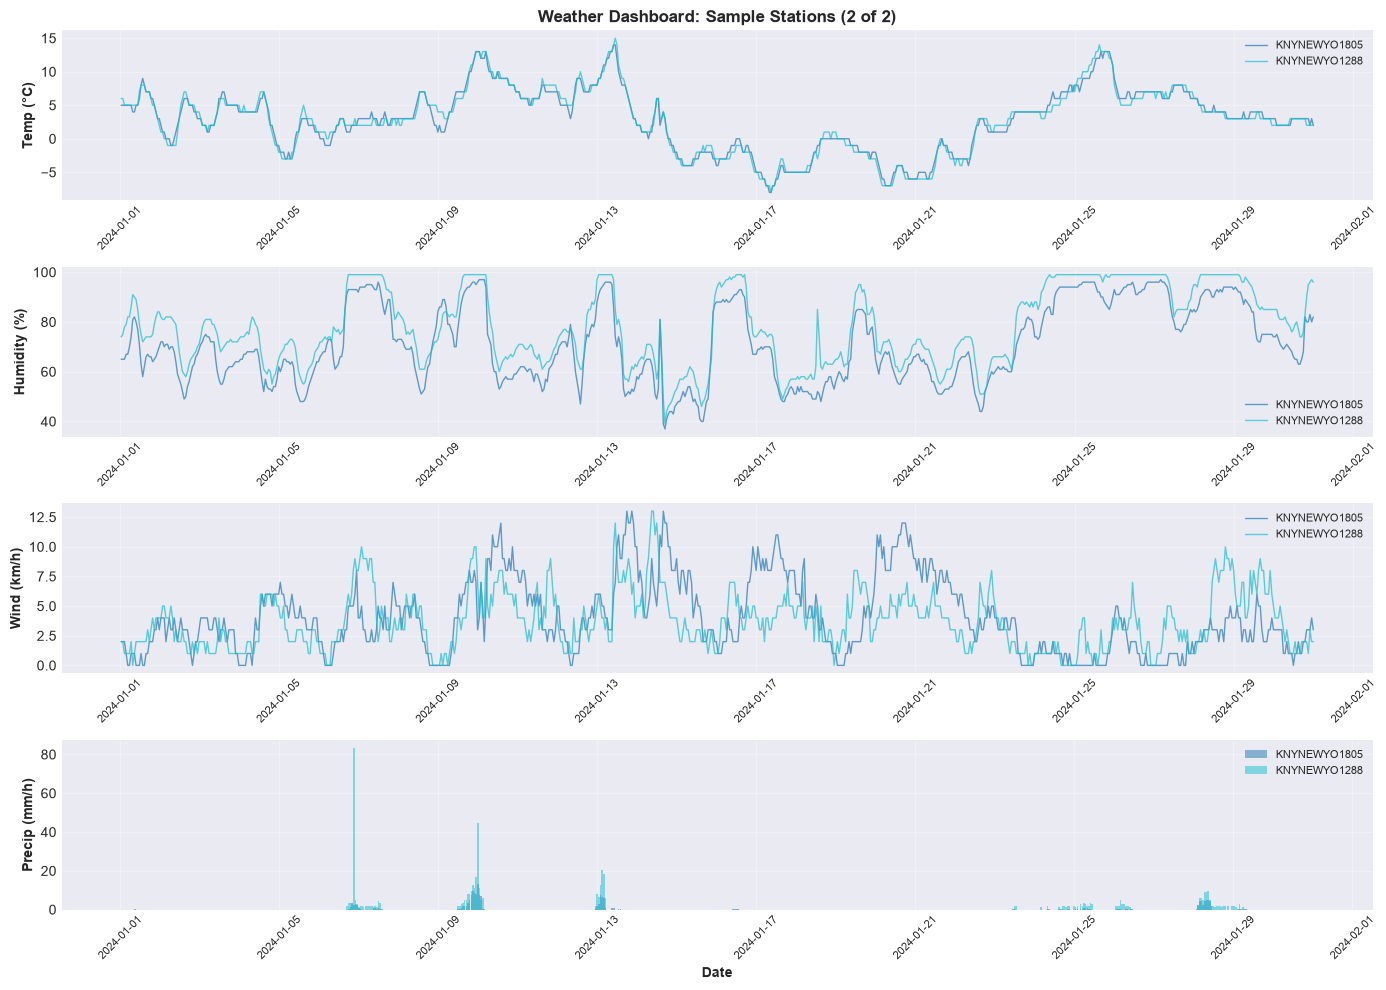

In [6]:
wup.plot_weather_dashboard_multi(stations, units=UNITS, show=True)

## Export

CSV and JSON per station, into `OUTPUT_DIR`. Off by default.

In [7]:
EXPORT = False
if EXPORT:
    wu.export_wu_data(results=results, output_dir=OUTPUT_DIR,
                      start_date=START, end_date=END, export_all=False)